In [1]:
import torch
from torch import nn
import torchvision
from torchvision import datasets
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt
print(f"PyTorch version: {torch.__version__}\ntorchvision version: {torchvision.__version__}")

PyTorch version: 2.10.0+cpu
torchvision version: 0.25.0+cpu


In [2]:
train_data = datasets.FashionMNIST(
    root = 'data',
    train = True,
    download = True,
    transform = ToTensor(),
    target_transform = None
)

test_data = datasets.FashionMNIST(
    root = 'data',
    train = False,
    download = True,
    transform = ToTensor()
)

In [3]:
image, label = train_data[0]
image,label
image.shape
len(train_data.data), len(train_data.targets), len(test_data.data), len(test_data.targets)
class_name = train_data.classes
class_name

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

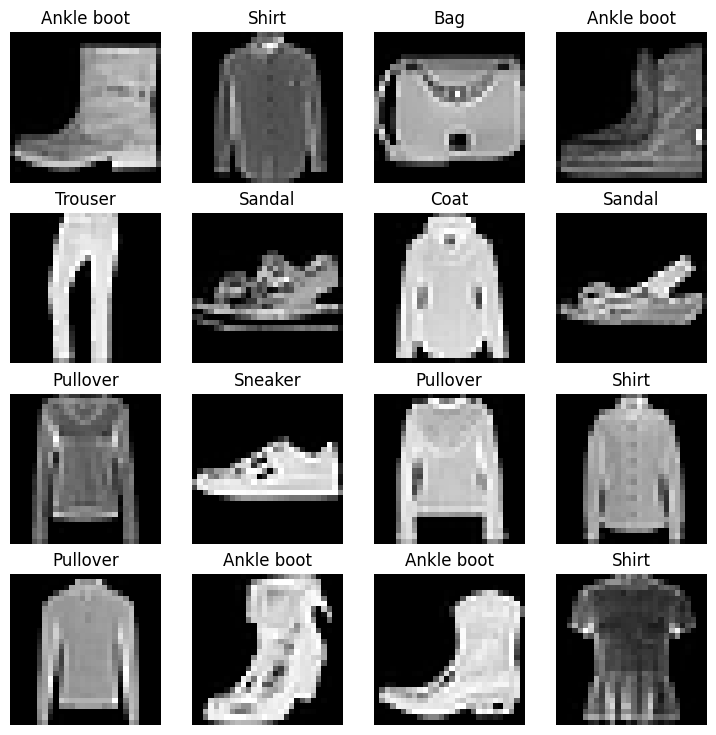

In [4]:
torch.manual_seed(42)
fig = plt.figure(figsize=(9,9))
rows,cols = 4,4
for i in range(1,rows*cols+1):
    random_idx = torch.randint(0,len(train_data),size=[1]).item()
    img, label = train_data[random_idx]
    fig.add_subplot(rows,cols,i)
    plt.imshow(img.squeeze(),cmap='gray')
    plt.title(class_name[label])
    plt.axis(False)

In [5]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_dataloader = DataLoader(train_data,batch_size=BATCH_SIZE,shuffle=True)
test_dataloader = DataLoader(test_data,batch_size=BATCH_SIZE,shuffle=False)

print(f"Dataloaders: {train_dataloader, test_dataloader}") 
print(f"Length of train dataloader: {len(train_dataloader)} batches of {BATCH_SIZE}")
print(f"Length of test dataloader: {len(test_dataloader)} batches of {BATCH_SIZE}")
train_features_batch, train_labels_batch = next(iter(train_dataloader))
train_features_batch.shape, train_labels_batch.shape

Dataloaders: (<torch.utils.data.dataloader.DataLoader object at 0x0000019537A92E40>, <torch.utils.data.dataloader.DataLoader object at 0x0000019537DFA2D0>)
Length of train dataloader: 1875 batches of 32
Length of test dataloader: 313 batches of 32


(torch.Size([32, 1, 28, 28]), torch.Size([32]))

In [6]:
flatten_model = nn.Flatten()

x = train_features_batch[0]

output = flatten_model(x)

print(f"Shape before flattening: {x.shape} -> [color_channels, height, width]")
print(f"Shape after flattening: {output.shape} -> [color_channels, height*width]")

Shape before flattening: torch.Size([1, 28, 28]) -> [color_channels, height, width]
Shape after flattening: torch.Size([1, 784]) -> [color_channels, height*width]


In [7]:
class FashionModel(nn.Module):
    def __init__(self,input_shape:int,hidden_unit:int,output_shape:int):
        super().__init__()
        self.linear_stack = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=input_shape,out_features=hidden_unit),
            nn.Linear(in_features=hidden_unit,out_features=output_shape)
        )

    def forward(self,x):
        return self.linear_stack(x)

In [8]:
torch.manual_seed(42)

model0 = FashionModel(
    input_shape = 784,
    hidden_unit = 10,
    output_shape = len(class_name)
)

model0

FashionModel(
  (linear_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=10, bias=True)
  )
)

In [9]:
import requests
from pathlib import Path 
from helper_functions import accuracy_fn

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model0.parameters(),lr=0.1)

In [10]:
torch.manual_seed(42)

epochs = 3

for epoch in range(epochs):
    print(f"Epoch: {epoch}\n--------------")
    train_loss = 0
    for batch,(X,y) in enumerate(train_dataloader):
        model0.train()
        y_preds = model0(X)
        loss = loss_fn(y_preds,y)
        train_loss += loss
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        if batch % 400 == 0:
            print(f"Looked at {batch * len(X)}/{len(train_dataloader.dataset)} samples")
    train_loss /= len(train_dataloader)

    test_loss,test_acc=0,0

    model0.eval()
    with torch.inference_mode():
        for X,y in test_dataloader:
            test_preds = model0(X)
            test_lossy = loss_fn(test_preds,y)
            test_loss += test_lossy
            test_acc += accuracy_fn(y_true=y,y_pred=test_preds.argmax(dim=1))
    
        test_loss /= len(test_dataloader)
        test_acc /= len(test_dataloader)

    print(f"\nTrain loss: {train_loss:.5f} | Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%\n")




Epoch: 0
--------------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples

Train loss: 0.59039 | Test loss: 0.50954, Test acc: 82.04%

Epoch: 1
--------------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples

Train loss: 0.47633 | Test loss: 0.47989, Test acc: 83.20%

Epoch: 2
--------------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples

Train loss: 0.45503 | Test loss: 0.47664, Test acc: 83.43%



In [11]:
torch.manual_seed(42)

def eval_model(model:torch.nn.Module,data_loader:torch.utils.data.DataLoader,loss_fn:torch.nn.Module,accuracy_fn):
    loss,acc = 0,0
    model.eval()
    with torch.inference_mode():
        for X,y in data_loader:
            y_preds = model(X)
            loss += loss_fn(y_preds,y)
            acc += accuracy_fn(y_true=y,y_pred=y_preds.argmax(dim=1))
        
        loss /= len(data_loader)
        acc /= len(data_loader)

    return {'model_name': model.__class__.__name__,
            'model_loss':loss.item(),
            'model_acc':acc}

model0_results = eval_model(model=model0,data_loader=test_dataloader,loss_fn=loss_fn,accuracy_fn=accuracy_fn)
model0_results

{'model_name': 'FashionModel',
 'model_loss': 0.47663894295692444,
 'model_acc': 83.42651757188499}

In [12]:
class FashionModel1(nn.Module):
    def __init__(self,input_shape:int,hidden_units:int,output_shape:int):
        super().__init__()

        self.LinearStack1 = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=input_shape,out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units,out_features=output_shape),
            nn.ReLU()
        )

    def forward(self,x:torch.Tensor):
        return self.LinearStack1(x)

In [13]:
model1 = FashionModel1(input_shape=784,hidden_units=10,output_shape=len(class_name))
model1

FashionModel1(
  (LinearStack1): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): ReLU()
    (3): Linear(in_features=10, out_features=10, bias=True)
    (4): ReLU()
  )
)

In [14]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model1.parameters(),lr=0.1)

In [15]:
def train_step(model:torch.nn.Module,data_loader:torch.utils.data.DataLoader,loss_fn:torch.nn.Module,optimizer:torch.optim.Optimizer,accuracy_fn):
    train_loss, train_acc = 0,0
    model.train()
    for batch,(X,y) in enumerate(data_loader):
        y_preds = model(X)
        loss = loss_fn(y_preds,y)
        train_loss += loss
        train_acc += accuracy_fn(y_true=y,y_pred=y_preds.argmax(dim=1))
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
    train_loss /= len(data_loader)
    train_acc /= len(data_loader)
    print(f"Train loss: {train_loss:.5f} | Train accuracy: {train_acc:.2f}%")

def test_step(model:torch.nn.Module,data_loader:torch.utils.data.DataLoader,loss_fn:torch.nn.Module,accuracy_fn):
    model.eval()
    test_loss, test_acc = 0,0
    with torch.inference_mode():
        for X,y in data_loader:
            test_preds = model(X)
            test_lossy = loss_fn(test_preds,y)
            test_loss += test_lossy
            test_acc += accuracy_fn(y_true=y,y_pred=test_preds.argmax(dim=1))

        test_loss /= len(data_loader)
        test_acc /= len(data_loader)
        print(f"Test loss: {test_loss:.5f} | Test accuracy: {test_acc:.2f}%\n")



In [16]:
torch.manual_seed(42)

epochs = 3

for epoch in range(epochs):
    print(f"Epochs: {epoch}\n--------------------")
    train_step(model=model1,data_loader=train_dataloader,loss_fn=loss_fn,optimizer=optimizer,accuracy_fn=accuracy_fn)
    test_step(model=model1,data_loader=test_dataloader,loss_fn=loss_fn,accuracy_fn=accuracy_fn)

Epochs: 0
--------------------
Train loss: 0.98248 | Train accuracy: 65.06%
Test loss: 0.76060 | Test accuracy: 72.80%

Epochs: 1
--------------------
Train loss: 0.70374 | Train accuracy: 74.43%
Test loss: 0.71959 | Test accuracy: 73.53%

Epochs: 2
--------------------
Train loss: 0.67371 | Train accuracy: 75.37%
Test loss: 0.69469 | Test accuracy: 74.71%



In [17]:
torch.manual_seed(42)

model1_results = eval_model(model=model1,data_loader=test_dataloader,loss_fn=loss_fn,accuracy_fn=accuracy_fn)
print(model0_results,"\n",model1_results)

{'model_name': 'FashionModel', 'model_loss': 0.47663894295692444, 'model_acc': 83.42651757188499} 
 {'model_name': 'FashionModel1', 'model_loss': 0.6946898698806763, 'model_acc': 74.71046325878594}


In [18]:
class FashionModel2(nn.Module):
    def __init__(self,input_shape:int,hidden_units:int,output_shape:int):
        super().__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape,
                    out_channels=hidden_units,
                    kernel_size=3,
                    stride=1,
                    padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units,
                    out_channels=hidden_units,
                    kernel_size=3,
                    stride=1,
                    padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,
                            stride=2)
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(hidden_units,hidden_units,3,padding=1),
            nn.ReLU(),
            nn.Conv2d(hidden_units,hidden_units,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=hidden_units*7*7,out_features=output_shape)
        )

    def forward(self,x:torch.Tensor):
        x = self.block1(x)
        x = self.block2(x)
        x = self.classifier(x)
        return x

model2 = FashionModel2(input_shape=1,hidden_units=10,output_shape=len(class_name))
model2

FashionModel2(
  (block1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

In [19]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model2.parameters(),lr=0.1)

In [20]:
torch.manual_seed(42)

epochs = 3

for epoch in range(epochs):
    print(f"Epoch: {epoch}\n----------------------")
    train_step(model=model2,data_loader=train_dataloader,loss_fn=loss_fn,optimizer=optimizer,accuracy_fn=accuracy_fn)
    test_step(model=model2,data_loader=test_dataloader,loss_fn=loss_fn,accuracy_fn=accuracy_fn)

Epoch: 0
----------------------
Train loss: 0.74134 | Train accuracy: 72.96%
Test loss: 0.39429 | Test accuracy: 85.88%

Epoch: 1
----------------------
Train loss: 0.36910 | Train accuracy: 86.62%
Test loss: 0.35093 | Test accuracy: 87.01%

Epoch: 2
----------------------
Train loss: 0.32781 | Train accuracy: 88.16%
Test loss: 0.33033 | Test accuracy: 87.90%



In [21]:
torch.manual_seed(42)

model2_results = eval_model(model=model2,data_loader=test_dataloader,loss_fn=loss_fn,accuracy_fn=accuracy_fn)

print(model0_results,"\n",model1_results,"\n",model2_results)

{'model_name': 'FashionModel', 'model_loss': 0.47663894295692444, 'model_acc': 83.42651757188499} 
 {'model_name': 'FashionModel1', 'model_loss': 0.6946898698806763, 'model_acc': 74.71046325878594} 
 {'model_name': 'FashionModel2', 'model_loss': 0.33033210039138794, 'model_acc': 87.89936102236422}


In [22]:
def make_predictions(model:torch.nn.Module,data:list):
    pred_probs = []
    model.eval()
    with torch.inference_mode():
        for sample in data:
            sample = torch.unsqueeze(sample,dim=0)
            pred_logits = model(sample)
            pred_prob = torch.softmax(pred_logits.squeeze(),dim=0)
            pred_probs.append(pred_prob.cpu())

    return torch.stack(pred_probs)

In [23]:
import random
random.seed(42)
test_samples = []
test_labels = []

for sample,label in random.sample(list(test_data),k=9):
    test_samples.append(sample)
    test_labels.append(label)

print(f"Test sample image shape {test_samples[0].shape}\nTest label {test_labels[0]} ({class_name[test_labels[0]]})")

Test sample image shape torch.Size([1, 28, 28])
Test label 5 (Sandal)


In [24]:
pred_probs = make_predictions(model=model2,data=test_samples)
pred_probs[:2]

tensor([[6.1976e-07, 1.1465e-08, 1.2382e-08, 2.1493e-08, 9.5671e-09, 9.9991e-01,
         2.2063e-06, 3.4166e-06, 2.0800e-05, 6.4739e-05],
        [5.2232e-03, 9.8220e-01, 3.0247e-04, 8.2402e-03, 2.8575e-03, 2.9536e-04,
         7.9400e-04, 1.8710e-05, 5.1529e-05, 1.2140e-05]])

In [25]:
pred_classes = pred_probs.argmax(dim=1)
pred_classes

tensor([5, 1, 7, 4, 3, 0, 4, 7, 1])

In [26]:
test_labels, pred_classes

([5, 1, 7, 4, 3, 0, 4, 7, 1], tensor([5, 1, 7, 4, 3, 0, 4, 7, 1]))

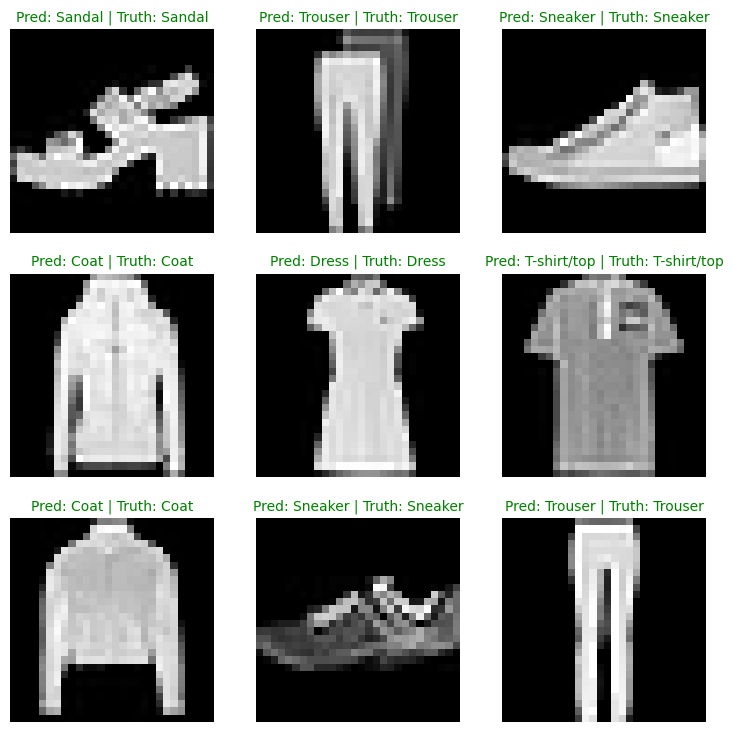

In [27]:
plt.figure(figsize=(9,9))
nrows = 3
ncols = 3
for i,sample in enumerate(test_samples):
    plt.subplot(nrows,ncols,i+1)
    plt.imshow(sample.squeeze(),cmap='grey')
    pred_label = class_name[pred_classes[i]]
    truth_label = class_name[test_labels[i]]
    title_text = f"Pred: {pred_label} | Truth: {truth_label}"

    if pred_label == truth_label:
        plt.title(title_text,fontsize=10,c='g')
    else:
        plt.title(title_text,fontsize=10,c='r')
    plt.axis(False)

In [28]:
from tqdm.auto import tqdm

y_preds = []
model2.eval()

with torch.inference_mode():
    for X,y in tqdm(test_dataloader,desc="Making Predictions"):
        y_logits = model2(X)
        y_pred = torch.softmax(y_logits,dim=1).argmax(dim=1)
        y_preds.append(y_pred.cpu())

y_pred_tensor = torch.cat(y_preds)

c:\Users\abhit\OneDrive\Documents\Programming Files\neuron\tf-env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Making Predictions: 100%|██████████| 313/313 [00:02<00:00, 152.51it/s]


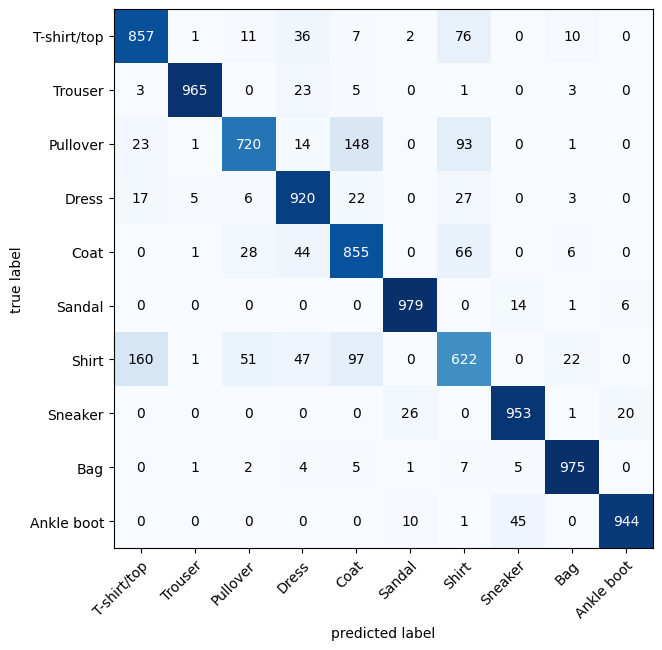

In [29]:
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix

confmat = ConfusionMatrix(num_classes=len(class_name),task='multiclass')
confmat_tensor = confmat(preds=y_pred_tensor,target=test_data.targets)

fig,ax = plot_confusion_matrix(
    conf_mat = confmat_tensor.numpy(),
    class_names = class_name,
    figsize = (10,7)
)